In [1]:
# Libs
import phobos
import numpy as np
import matplotlib.pyplot as plt
import time
import pickle
from tqdm import tqdm

✅ BMC lib found. Running in control mode.


In [2]:
# Constants
lam = 1550 # [nm]

In [27]:
chip2 = phobos.Arch5()
chip2.shifters[0].power_dac_calibration(verbose=True)
chip2.shifters[3].set_power(0.)

🔧 Calibrating channel 4 using 2-point measurement...
📤 XPOW TX: 'CH:4:CUR:65535'
📥 Output disabled
📤 XPOW TX: 'CH:4:VOLT:1638'
📥 Output disabled
📤 XPOW TX: 'CH:4:VAL?'
📥 XPOW RX: 'CH:4:VAL?	>> Channel 4 = 1.002V, 1.125mA'
📤 XPOW TX: 'CH:4:VAL?'
📥 XPOW RX: 'CH:4:VAL?	>> Channel 4 = 1.012V, 1.152mA'
📤 XPOW TX: 'CH:4:VOLT:49151'
📥 Output disabled
📤 XPOW TX: 'CH:4:VAL?'
📥 XPOW RX: 'CH:4:VAL?	>> Channel 4 = 28.298V, 38.437mA'
📤 XPOW TX: 'CH:4:VAL?'
📥 XPOW RX: 'CH:4:VAL?	>> Channel 4 = 28.298V, 38.465mA'
✅ Channel 4 calibrated: slope=0.001367
📤 XPOW TX: 'CH:4:CUR:0'
📥 Output disabled
📤 XPOW TX: 'CH:4:VOLT:0'
📥 Output disabled
✅ Channel 4 turned off.


In [3]:
# shortcuts
dm = phobos.DM()
cam = phobos.Cred3()
chip = phobos.Arch6()
inj_seg = phobos.Config().get('injection.segments')
print('Injected segments:', inj_seg)

# Setup
path = phobos.archive.new('ABCD_fringe_tracking1550nm', verbose=True)


DEBUG - SDK Install Path: /opt/Boston Micromachines
DEBUG - BMC_PCIeOpenDM 27BW007#051 0
DEBUG - 1 BMC PCIe cards installed.
DEBUG - Using automatic devId: 1
DEBUG - BMC_PCIeOpenDM opening 0
INFO - PCIe HW Rev: 20000502
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
INFO - Loading calibration for DM: 27BW07#051_5_3_setof14
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
Cred3 camera initialized with dark subtraction
Injected segments: [138, 137, 136, 135]
Archive created at /mnt/disk1/archive/2026-03-20_68dd9cb/4_ABCD_fringe_tracking1550nm


Scanning injection maps:   0%|          | 0/4 [00:00<?, ?it/s]

Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])


Scanning injection maps:  25%|██▌       | 1/4 [00:07<00:22,  7.44s/it]

Injection OFF on channels [0] (segments [138])
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])


Scanning injection maps:  50%|█████     | 2/4 [00:15<00:16,  8.01s/it]

...

Scanning injection maps:  75%|███████▌  | 3/4 [00:23<00:08,  8.05s/it]

Injection OFF on channels [2] (segments [136])
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])


Scanning injection maps: 100%|██████████| 4/4 [00:31<00:00,  7.92s/it]

Injection OFF on channels [3] (segments [135])
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])

── Find gross TT for max injection and spread ──
Injection max of seg=138: (tip, tilt) = (-0.83702,-0.00718) mrad
Injection spread of seg=138: (tip, tilt) = (0.65163,0.81670) mrad
Injection max of seg=137: (tip, tilt) = (-0.32623,-0.08687) mrad
Injection spread of seg=137: (tip, tilt) = (0.78146,0.73052) mrad
Injection max of seg=136: (tip, tilt) = (-0.00592,-0.23643) mrad
Injection spread of seg=136: (tip, tilt) = (0.70976,0.83631) mrad
Injection max of seg=135: (tip, tilt) = (0.19532,-0.24701) mrad
Injection spread of seg=135: (tip, tilt) = (0.72563,0.87477) mrad

── Find precise TT for max injection ──
Injection max of seg=138: (tip, tilt) = (-0.83865,0.01268) mrad; flux = 1239
Injection max of seg=137: (tip, tilt) = (-0.34099,-0.08248) mrad; flux = 1182
Injection max of seg=136: (tip, tilt) = (-0.01370,-0.23969) mrad; flux = 1207
Injection max of seg=135: (tip, ti


── Finding maximum injection points ──

── Balancing injection fluxes ──
  Weakest channel: 2 (seg 136), target flux = 1097
  Dichotomy on channel 0 (seg 138)…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])
    → balanced tilt = -0.2838 mrad, flux = 1095 (target 1097), iterations = 12
  Dichotomy on channel 1 (seg 137)…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])
    → balanced tilt = 0.2164 mrad, flux = 1086 (target 1097), iterations = 12
  Dichotomy on channel 3 (seg 135)…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])
    → balanced tilt = -0.1027 mrad, flux = 1091 (target 1097), iterations = 12
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
✅ Injection calibration saved to config (injection.balanced)


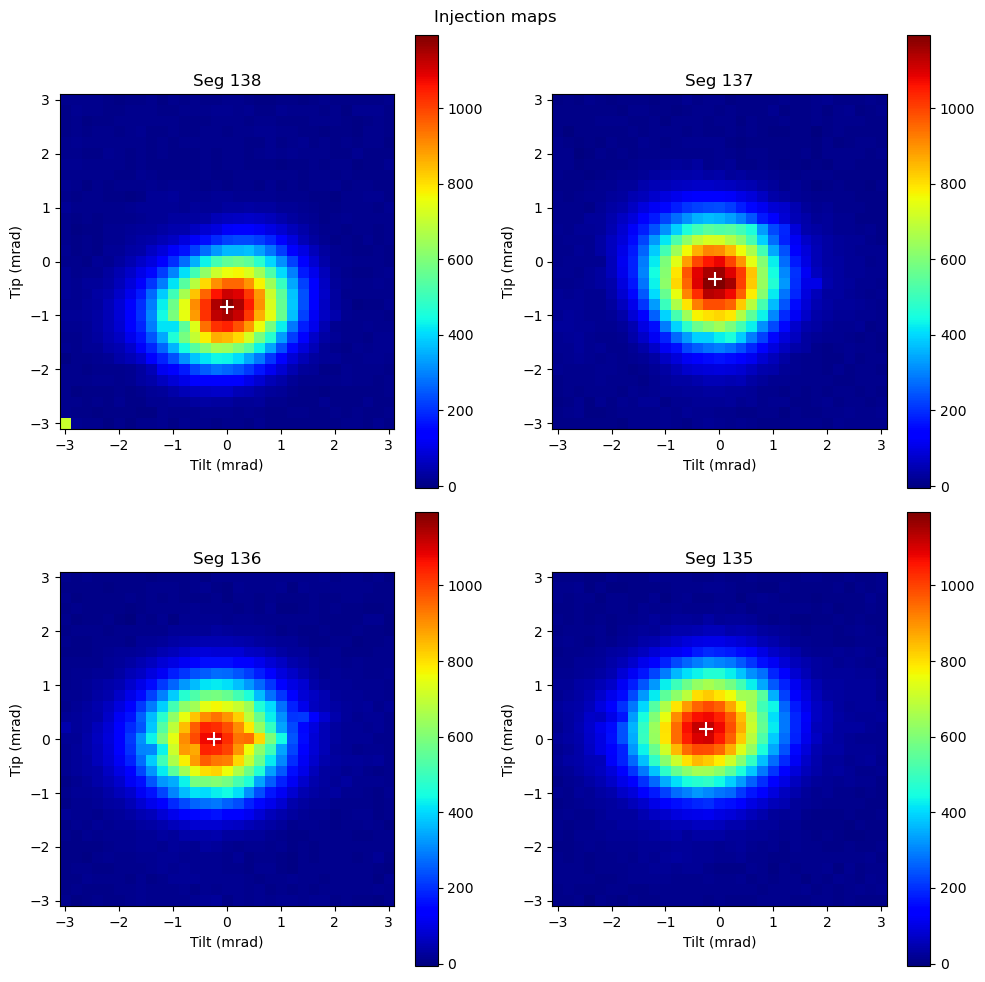

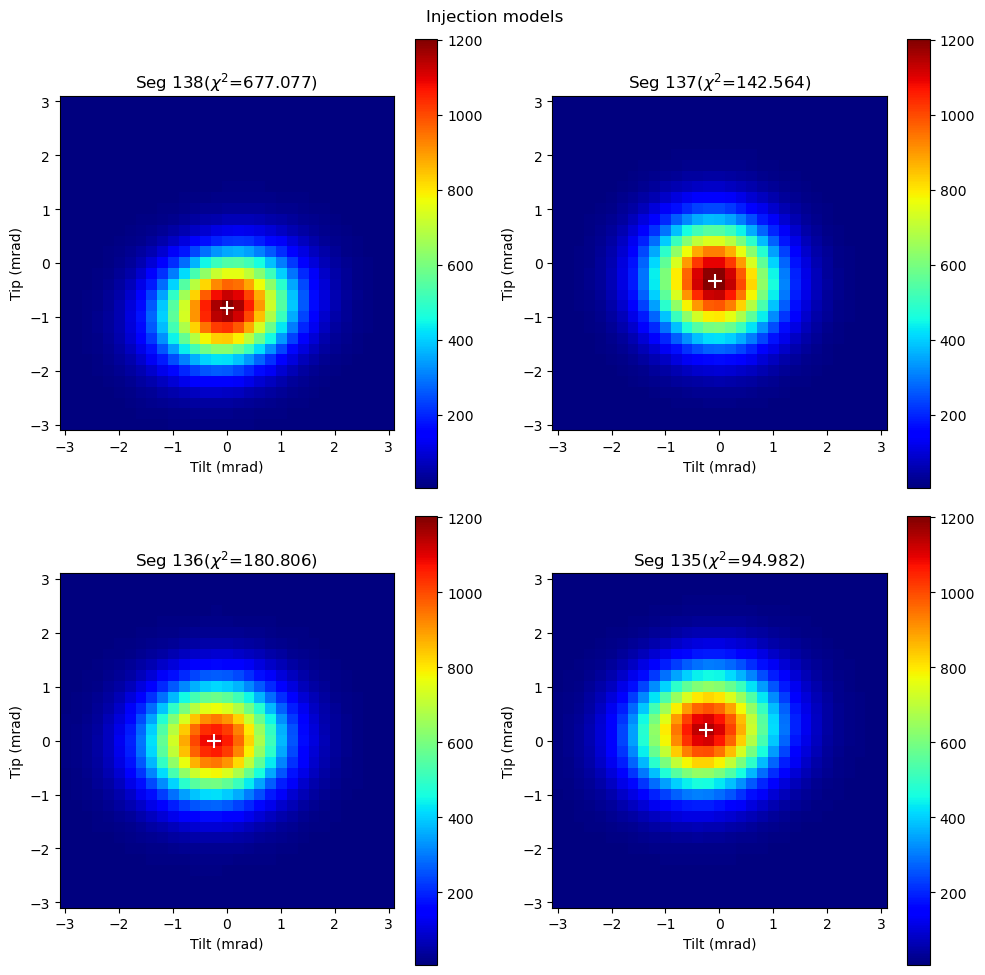

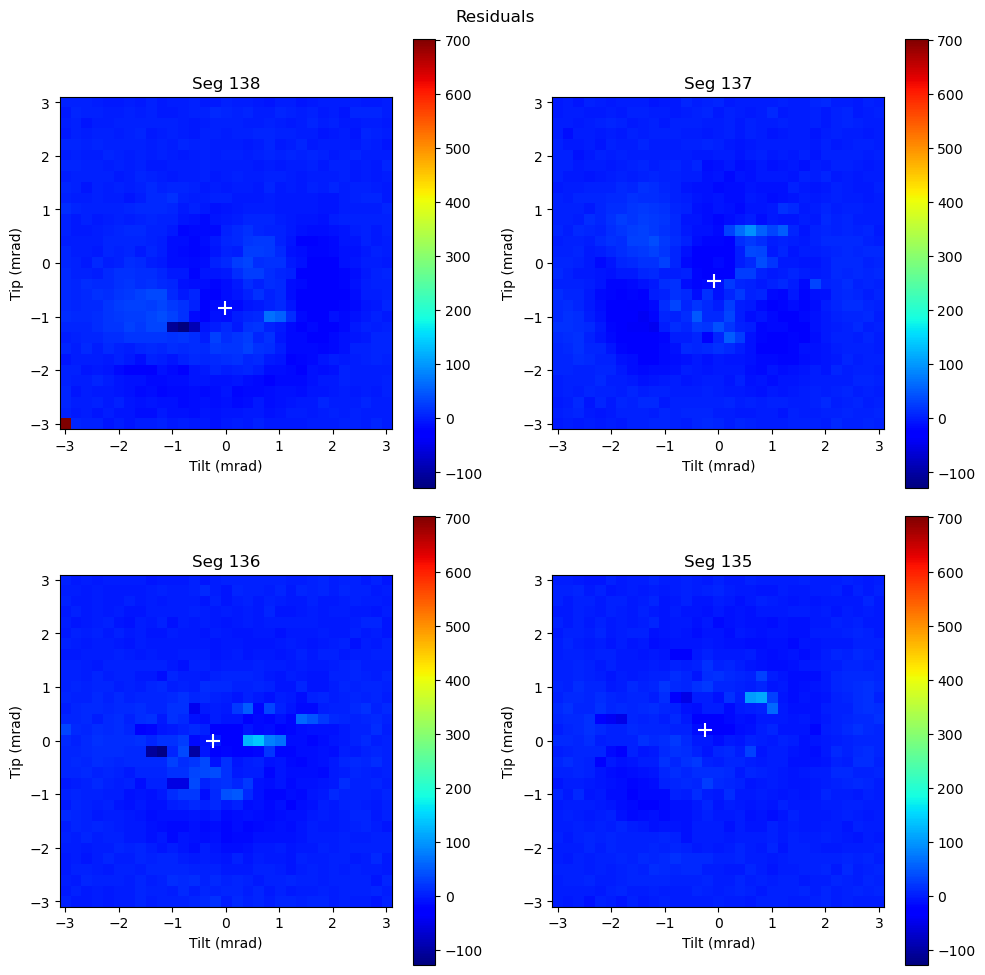

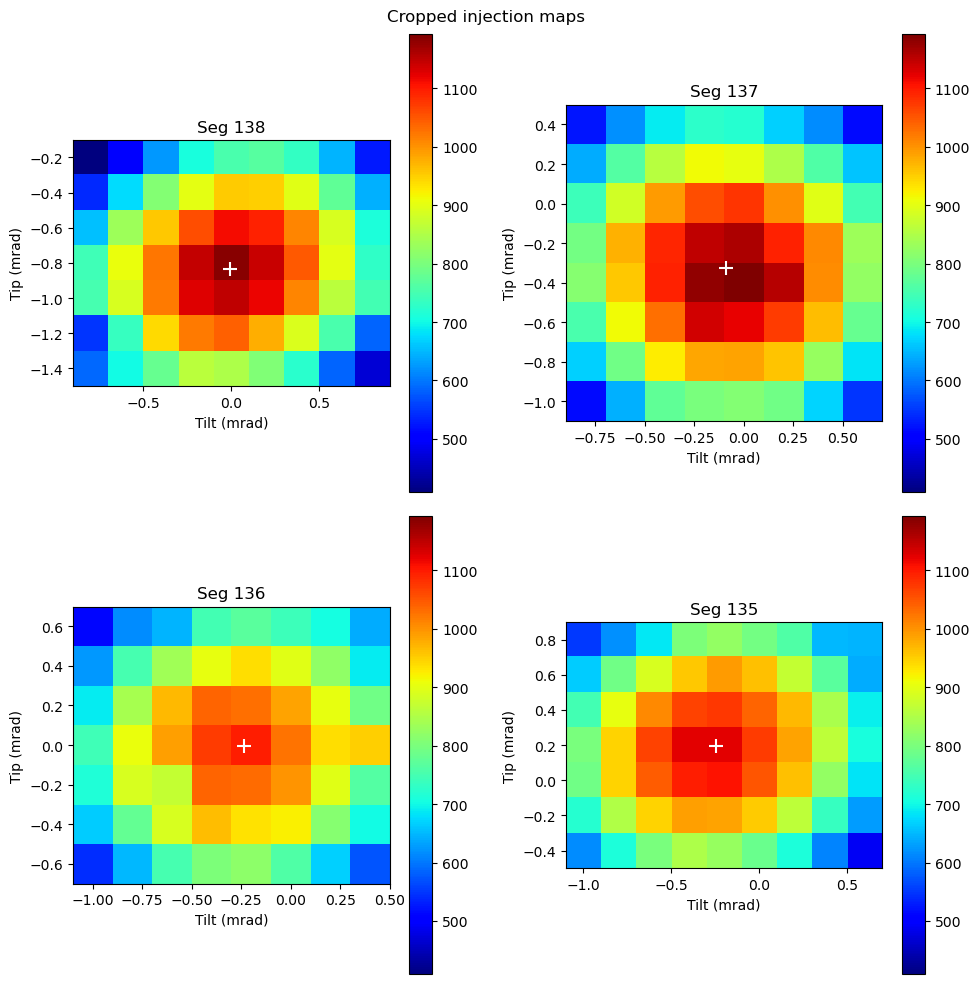

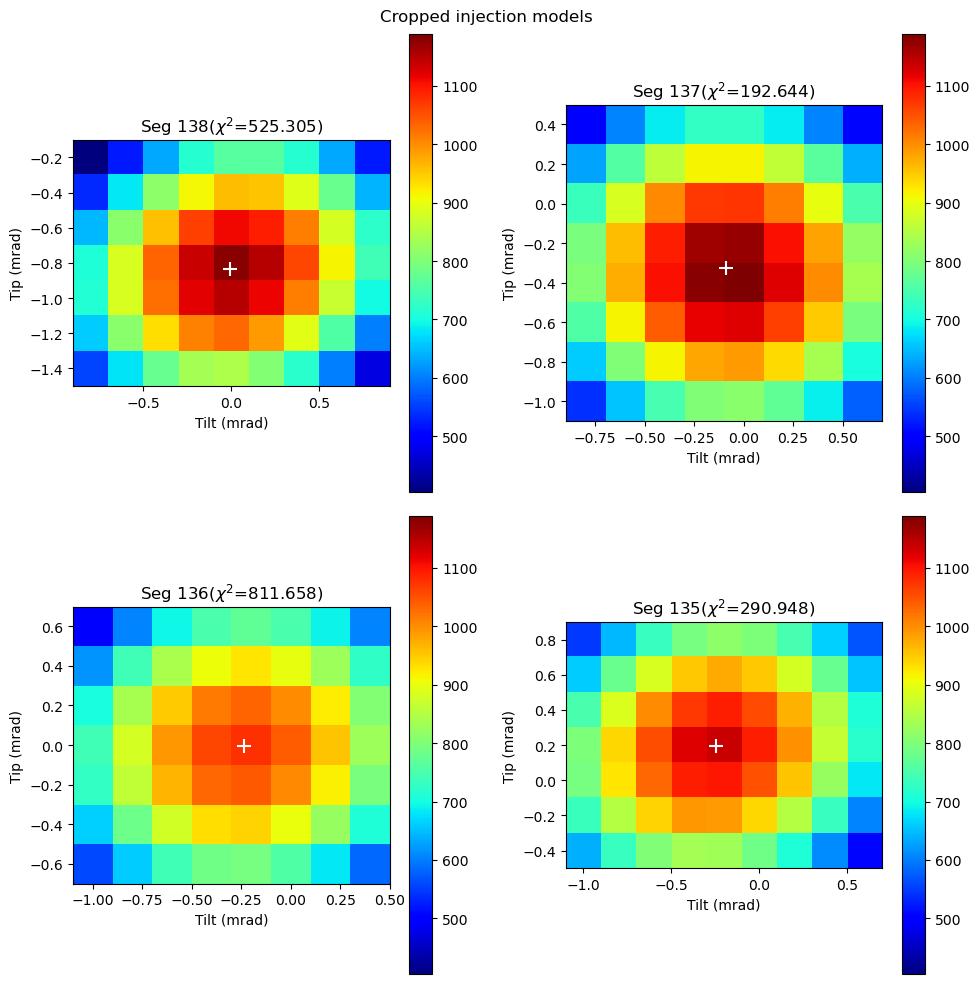

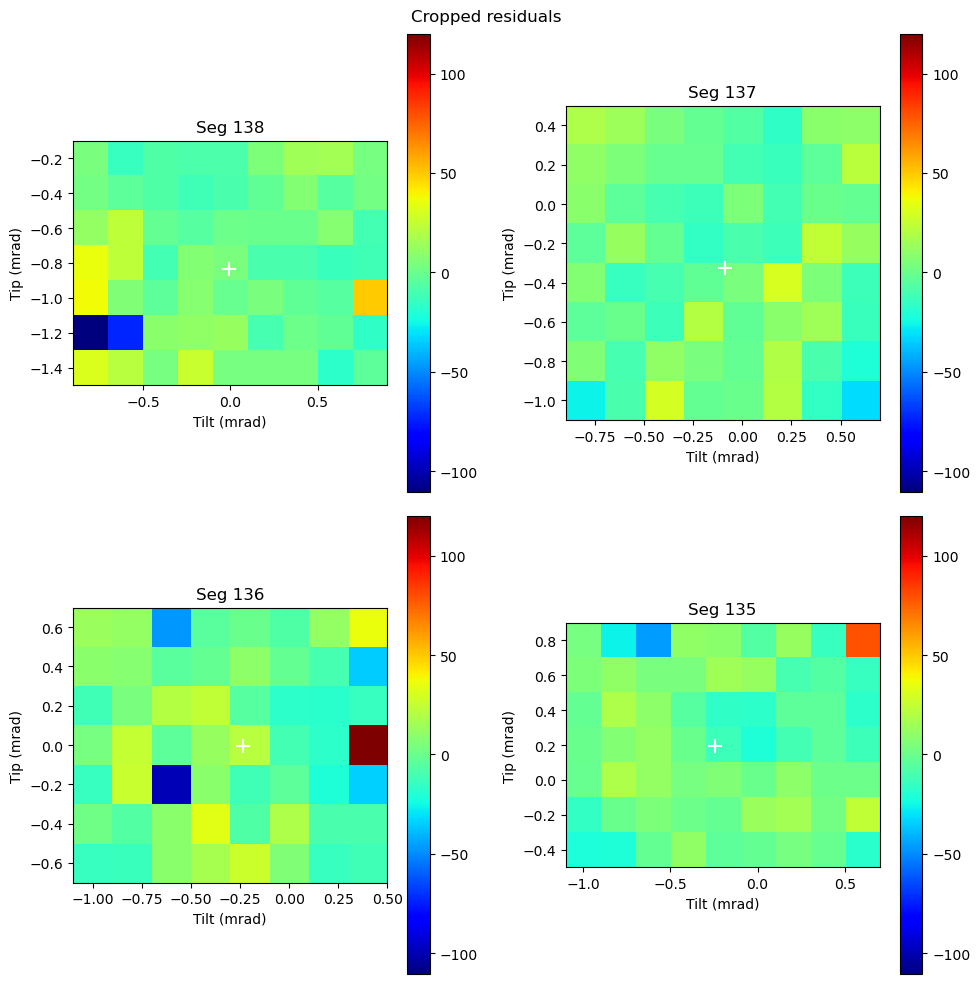

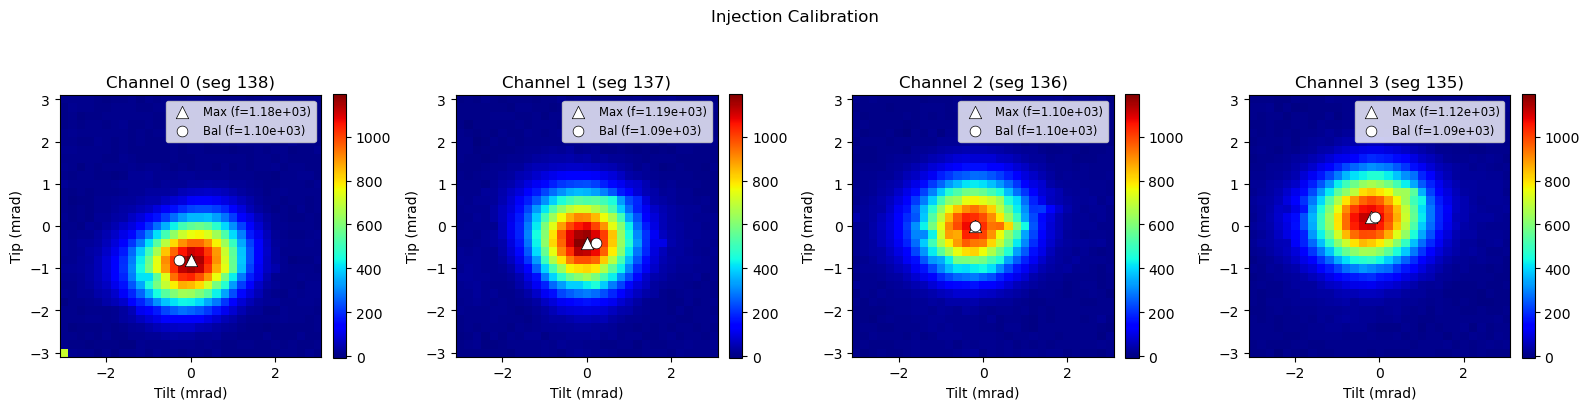

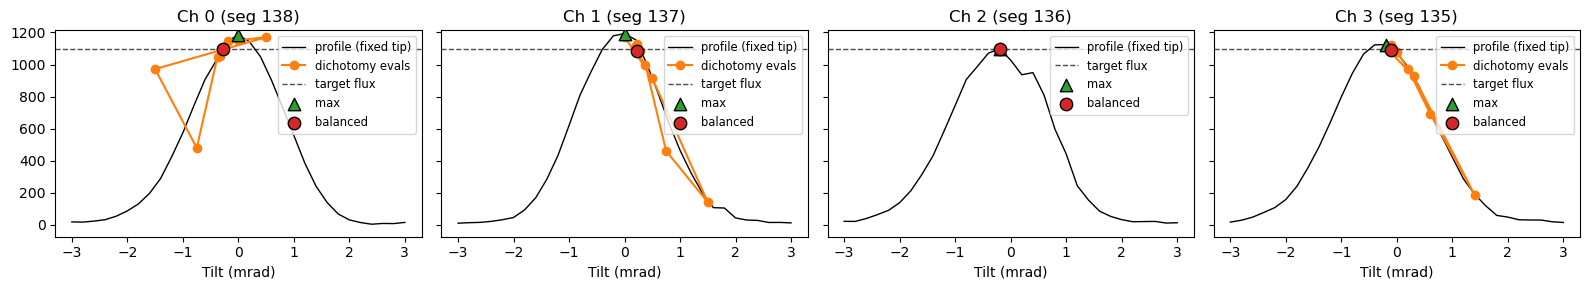

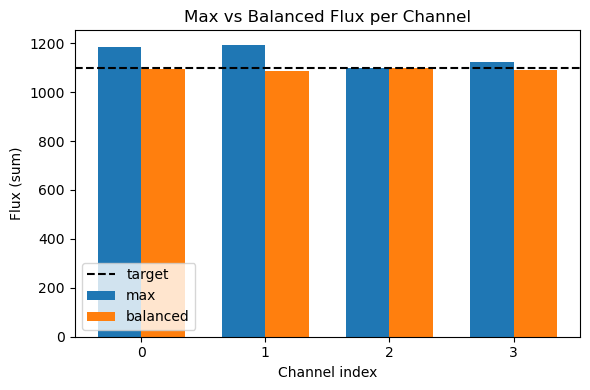

Successfully saved in FITS
Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


In [4]:
# Injection calibration
inj = phobos.Injection()
avg_frame = 1
out_inj = inj.calibrate(verbose=True, plot=True, save_path=path, avg_frames=avg_frame)

inj.set_balanced()

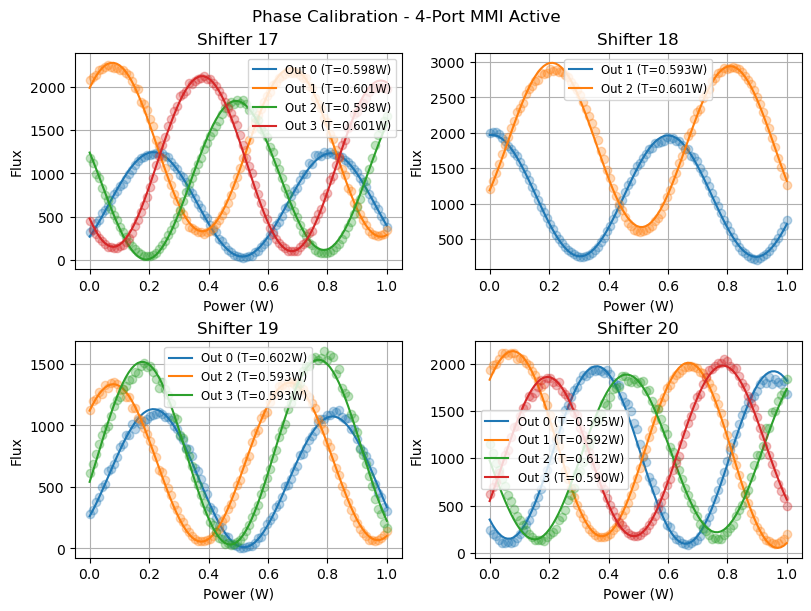

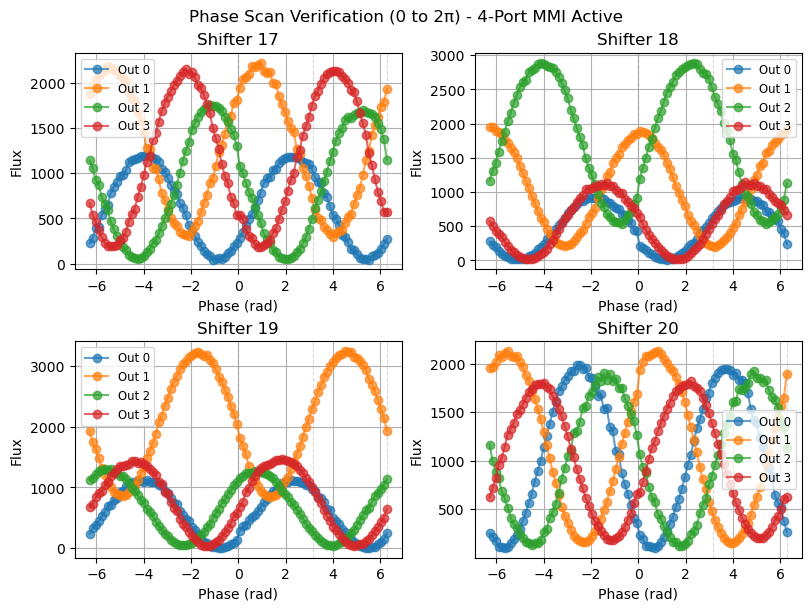

array([[[ 318.56417847, 2075.41796875, 1173.62780762,  444.89086914],
        [ 357.38235474, 2115.14526367, 1122.23120117,  350.15533447],
        [ 431.36584473, 2139.04614258,  995.71057129,  304.16360474],
        ...,
        [ 507.68814087,  283.84768677, 1524.25598145, 1994.01501465],
        [ 445.72119141,  301.76507568, 1603.78491211, 1991.37036133],
        [ 381.37408447,  343.62457275, 1666.83447266, 1979.32897949]],

       [[ 248.87825012, 2002.54199219, 1207.76013184,  556.35375977],
        [ 205.08485413, 2015.77331543, 1314.59472656,  506.94876099],
        [ 176.06832886, 2008.15356445, 1426.22290039,  449.16360474],
        ...,
        [ 934.32452393,  599.79815674, 1514.46252441,  942.36199951],
        [ 947.57244873,  682.04608154, 1390.18151855,  966.98187256],
        [ 962.4732666 ,  763.78991699, 1263.33862305,  993.56036377]],

       [[ 277.93606567, 1923.55847168, 1128.76831055,  617.12237549],
        [ 314.32452393, 1799.35192871, 1199.04101562,  686.1

In [5]:
# TOPAs calibration
chip.phase_calibration(plot=True, verbose=False)

# Mono-beam scan

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0] (segments [138])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1] (segments [137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [2] (segments [136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [3] (segments [135])
Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


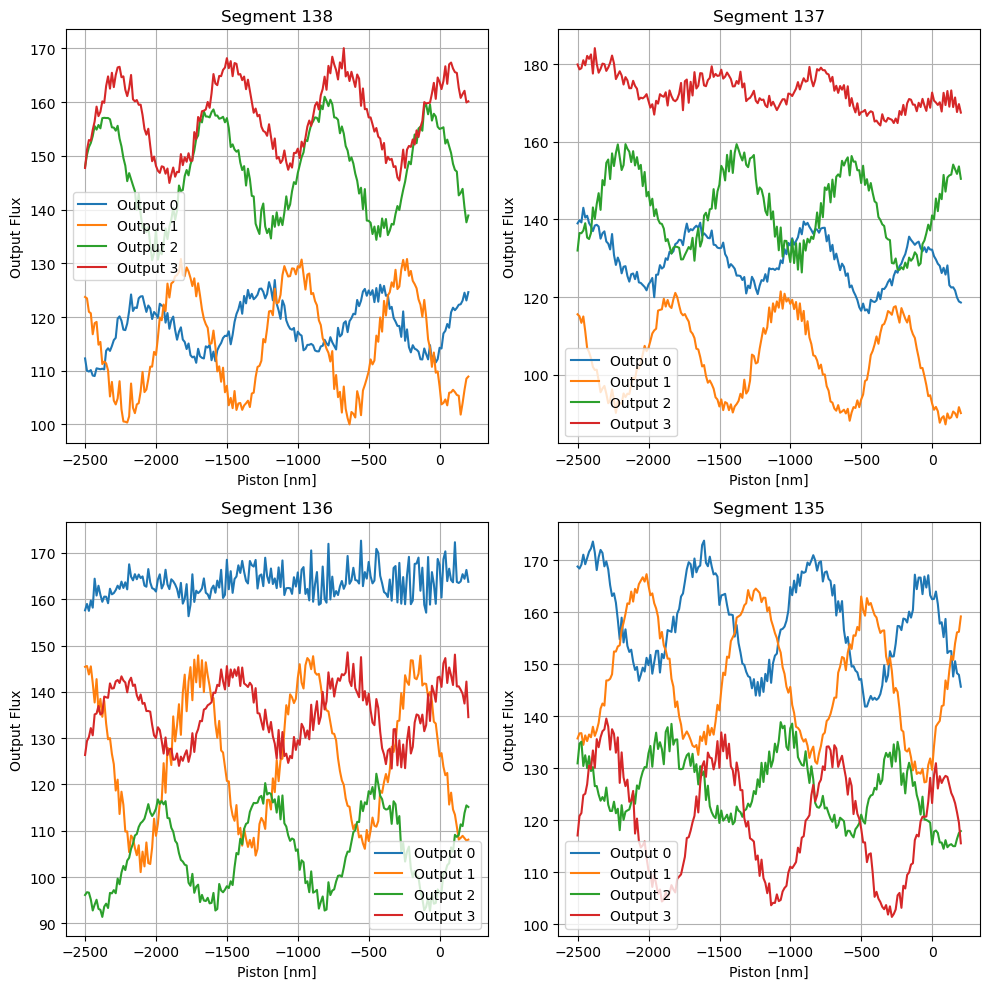

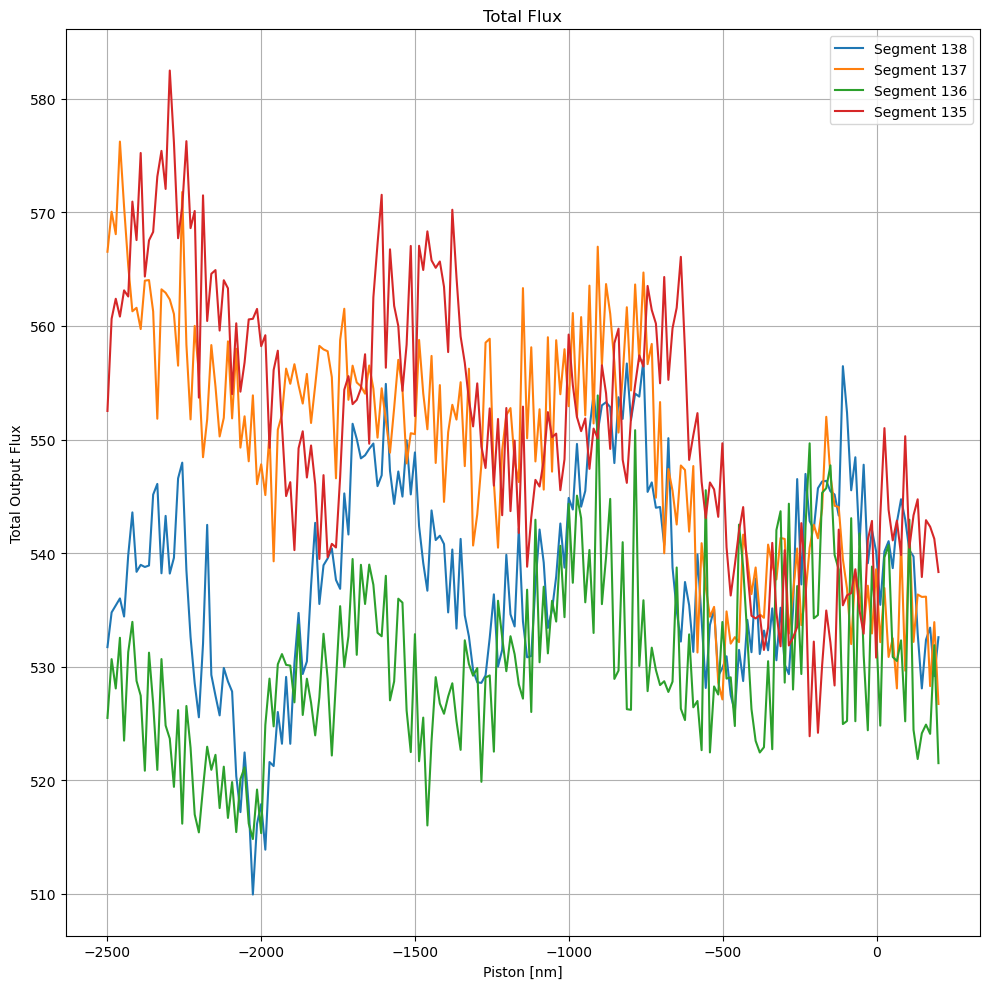

In [11]:
piston_range = np.linspace(-2500, 200, 201)  # [nm]
n_ch = len(inj_seg)
res_single_scan = {}
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

total_flux = []
for beam in range(n_ch):
    inj.off()
    inj.set_balanced(beam)

    outs = np.empty((len(piston_range), 4))
    for p, opd in enumerate(piston_range):
        dm[inj_seg[beam]].set_piston(opd)
        outs[p] = cam.get_outputs(flux_mode='mean')

    res_single_scan[inj_seg[beam]] = outs.copy()
    total_flux.append(outs[:].sum(axis=1))

    for o in range(4):
        axs[beam].plot(piston_range, outs[:, o], color=colors[o], linestyle='-', label=f'Output {o}')

    axs[beam].set_title(f'Segment {inj_seg[beam]}')
    axs[beam].set_xlabel('Piston [nm]')
    axs[beam].set_ylabel('Output Flux')
    axs[beam].legend()
    axs[beam].grid()


fig.tight_layout()
fig.savefig(path / 'singlebeam_scan_max.png')

total_flux = np.array(total_flux)
fig, axs = plt.subplots(1, 1, figsize=(10, 10))

for o in range(4):
    axs.plot(piston_range, total_flux[o], color=colors[o], linestyle='-', label=f'Segment {inj_seg[o]}')

axs.set_title('Total Flux')
axs.set_xlabel('Piston [nm]')
axs.set_ylabel('Total Output Flux')
axs.legend()
axs.grid()
fig.tight_layout()
fig.savefig(path / 'singlebeam_scan_balanced_totalflux.png')

inj.set_balanced()


Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection MAX on channels [0] (segments [138])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection MAX on channels [1] (segments [137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection MAX on channels [2] (segments [136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection MAX on channels [3] (segments [135])
Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


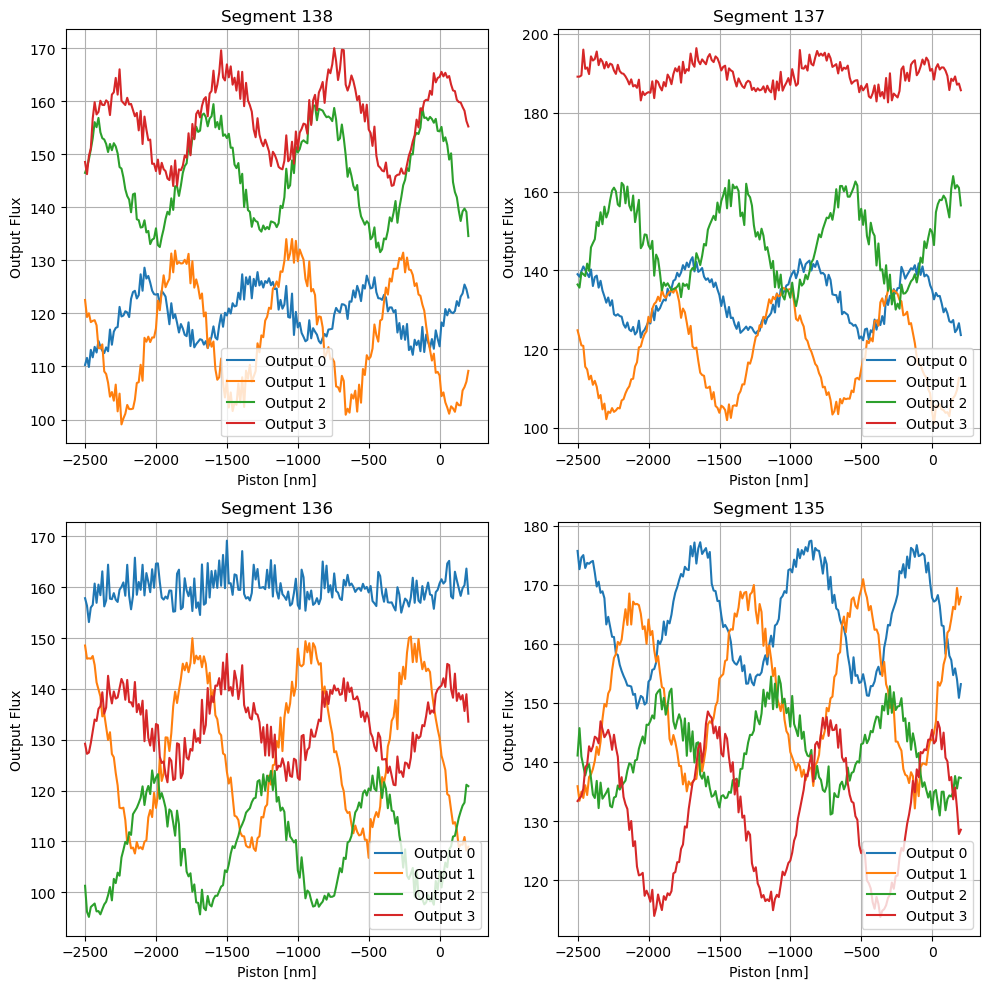

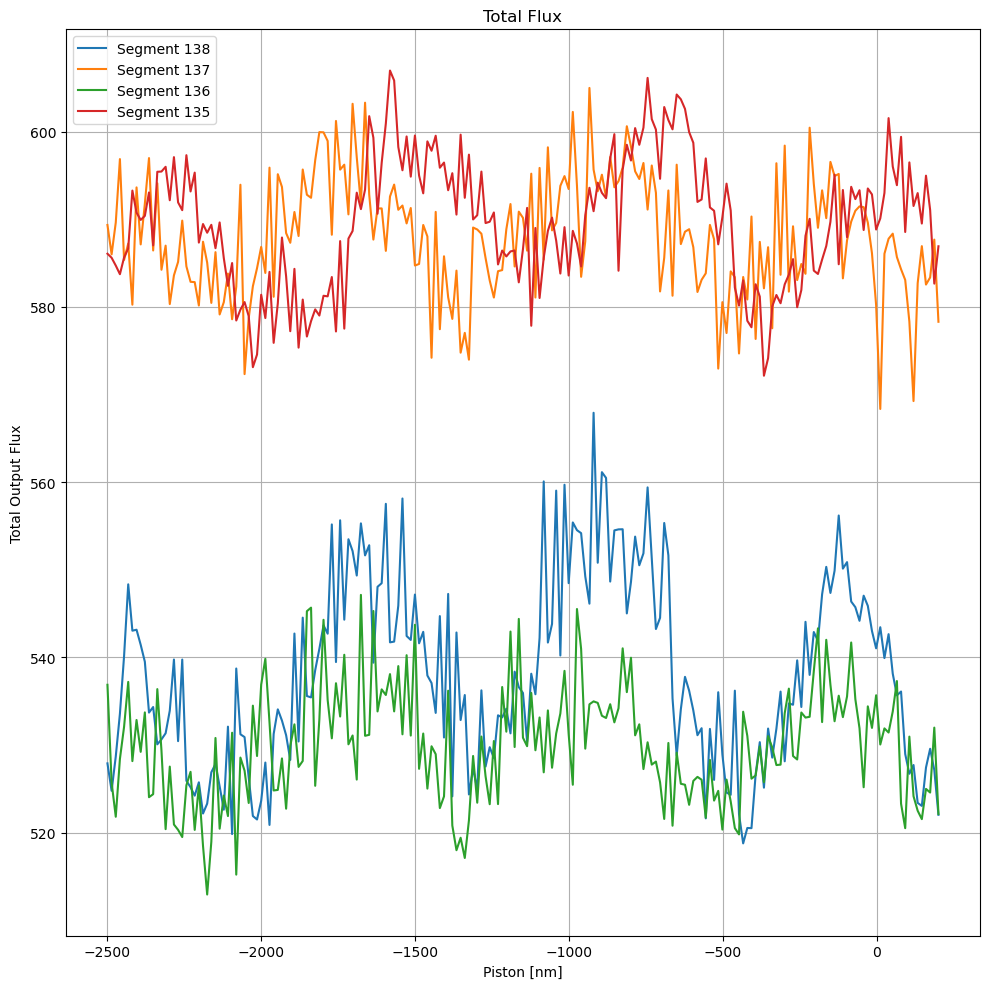

In [12]:
piston_range = np.linspace(-2500, 200, 201)  # [nm]
n_ch = len(inj_seg)
res_single_scan = {}
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

total_flux = []
for beam in range(n_ch):
    inj.off()
    inj.set_max(beam)

    outs = np.empty((len(piston_range), 4))
    for p, opd in enumerate(piston_range):
        dm[inj_seg[beam]].set_piston(opd)
        outs[p] = cam.get_outputs(flux_mode='mean')

    res_single_scan[inj_seg[beam]] = outs.copy()
    total_flux.append(outs[:].sum(axis=1))

    for o in range(4):
        axs[beam].plot(piston_range, outs[:, o], color=colors[o], linestyle='-', label=f'Output {o}')

    axs[beam].set_title(f'Segment {inj_seg[beam]}')
    axs[beam].set_xlabel('Piston [nm]')
    axs[beam].set_ylabel('Output Flux')
    axs[beam].legend()
    axs[beam].grid()


fig.tight_layout()
fig.savefig(path / 'singlebeam_scan_max.png')

total_flux = np.array(total_flux)
fig, axs = plt.subplots(1, 1, figsize=(10, 10))

for o in range(4):
    axs.plot(piston_range, total_flux[o], color=colors[o], linestyle='-', label=f'Segment {inj_seg[o]}')

axs.set_title('Total Flux')
axs.set_xlabel('Piston [nm]')
axs.set_ylabel('Total Output Flux')
axs.legend()
axs.grid()
fig.tight_layout()
fig.savefig(path / 'singlebeam_scan_max_totalflux.png')

inj.set_balanced()

# Pair scan

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 2] (segments [137, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BA

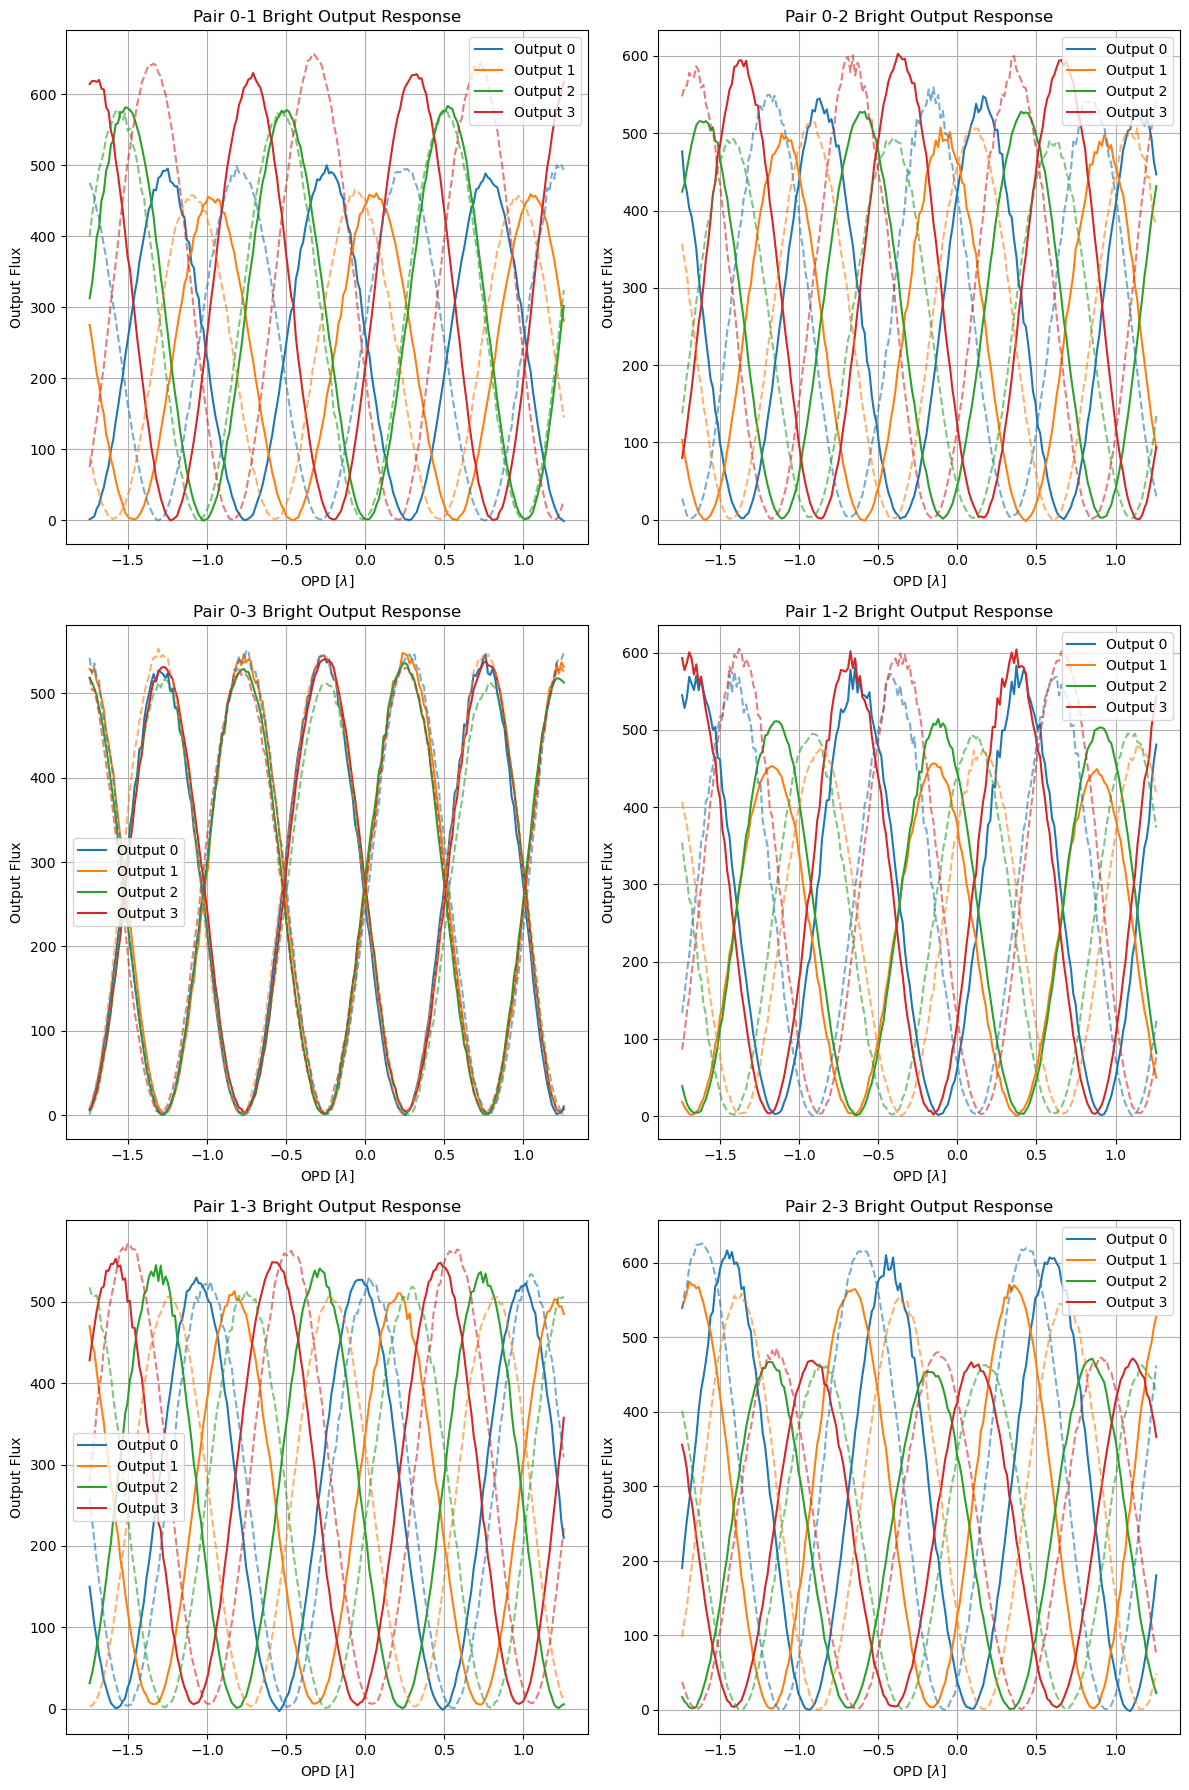

In [13]:
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
start = -2500 # nm
nb_lam = 3.

piston_range = np.linspace(start, start + nb_lam * lam/2., 201)  # [nm]


res_pair_scan = {}

fig, axs = plt.subplots(3, 2, figsize=(12, 18))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for i, pair in enumerate(pairs):
    inj.off()
    inj.set_balanced(np.array(pair))

    ref_cart = dm[inj_seg[pair[1]]].get_piston()
    opd_range = (piston_range - ref_cart) * 2

    dm[inj_seg[pair[1]]].set_piston(ref_cart)
    # Scan on first input
    outs = np.empty((len(piston_range), 4))
    for p, piston in enumerate(piston_range):
        dm[inj_seg[pair[0]]].set_piston(piston)
        outs[p] = cam.get_outputs(flux_mode='mean')

    data = np.hstack((opd_range[:,None], outs.copy()))
    res_pair_scan[(pair[0], pair[1])] = data

    for o in range(4):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], label=f'Output {o}')

    # Scan on second input
    inj.off()
    inj.set_balanced(np.array(pair))

    dm[inj_seg[pair[0]]].set_piston(ref_cart)
    outs = np.empty((len(piston_range), 4))
    for p, piston in enumerate(piston_range):
        dm[inj_seg[pair[1]]].set_piston(piston)
        outs[p] = cam.get_outputs(flux_mode='mean')

    data = np.hstack((opd_range[:,None], outs.copy()))
    res_pair_scan[(pair[1], pair[0])] = data

    for o in range(4):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], linestyle='--', alpha=0.6)
    
    axs[i].set_title(f'Pair {pair[0]}-{pair[1]} Bright Output Response')
    axs[i].set_xlabel(r'OPD [$\lambda$]')
    axs[i].set_ylabel('Output Flux')
    axs[i].legend()
    axs[i].grid()

fig.tight_layout()
fig.savefig(path / 'pair_scan.png')

with open(path / 'pair_scan_data.pkl', 'wb') as f:
    pickle.dump(res_pair_scan, f)


inj.set_balanced()

# Piston ramp with counter phase shift

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 2] (segments [137, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BA

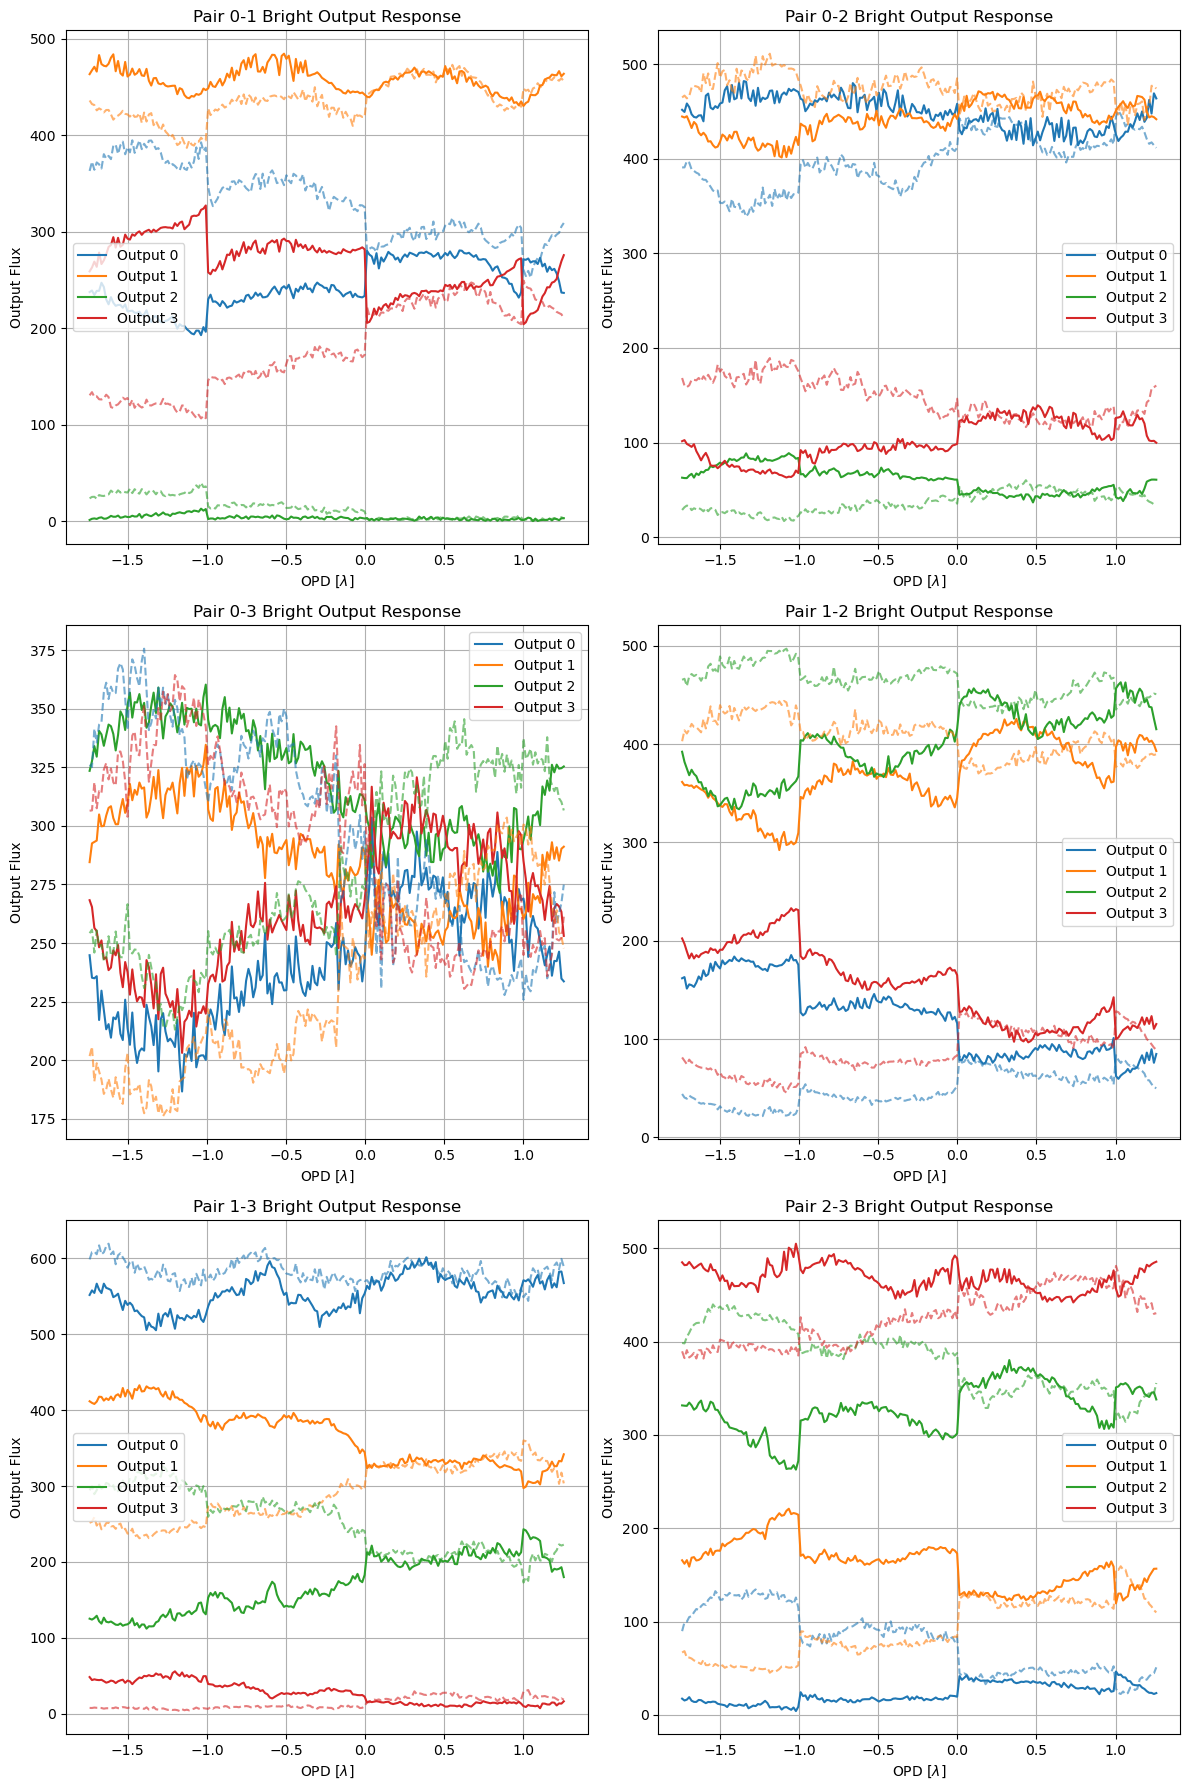

In [14]:
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
start = -2500 # nm
nb_lam = 3.

piston_range = np.linspace(start, start + nb_lam * lam/2., 201)  # [nm]


res_ramp_scan = {}

fig, axs = plt.subplots(3, 2, figsize=(12, 18))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for i, pair in enumerate(pairs):
    # Scan on first input
    inj.off()
    inj.set_balanced(np.array(pair))

    ref_cart = dm[inj_seg[pair[1]]].get_piston()
    opd_range = (piston_range - ref_cart) * 2

    dm[inj_seg[pair[1]]].set_piston(ref_cart)
    outs = np.empty((len(piston_range), 4))
    for p, piston in enumerate(piston_range):
        phase = 2 * np.pi / lam * opd_range[p]
        phase = phase % (2 * np.pi)
        phases = np.zeros(4)
        phases[pair[0]] = phase
        chip.set_phases(phases)
        dm[inj_seg[pair[0]]].set_piston(piston)
        outs[p] = cam.get_outputs(flux_mode='mean')

    phases[pair[0]] = 0.
    chip.set_phases(phases)

    data = np.hstack((opd_range[:,None], outs.copy()))
    res_ramp_scan[(pair[0], pair[1])] = data

    for o in range(4):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], label=f'Output {o}')

    # Scan on second input
    inj.off()
    chip.set_phases([0,0,0,0])
    inj.set_balanced(np.array(pair))

    ref_cart = dm[inj_seg[pair[0]]].get_piston()
    opd_range = (piston_range - ref_cart) * 2    

    dm[inj_seg[pair[0]]].set_piston(ref_cart)
    outs = np.empty((len(piston_range), 4))
    for p, piston in enumerate(piston_range):
        phase = 2 * np.pi / lam * opd_range[p]
        phase = phase % (2 * np.pi)
        phases = np.zeros(4)
        phases[pair[1]] = phase
        chip.set_phases(phases)        
        dm[inj_seg[pair[1]]].set_piston(piston)
        outs[p] = cam.get_outputs(flux_mode='mean')

    phases[pair[1]] = 0.
    chip.set_phases(phases)
    data = np.hstack((opd_range[:,None], outs.copy()))
    res_pair_scan[(pair[1], pair[0])] = data

    for o in range(4):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], linestyle='--', alpha=0.6)        

    axs[i].set_title(f'Pair {pair[0]}-{pair[1]} Bright Output Response')
    axs[i].set_xlabel(r'OPD [$\lambda$]')
    axs[i].set_ylabel('Output Flux')
    axs[i].legend()
    axs[i].grid()
    

fig.tight_layout()
fig.savefig(path / 'ramp.png')

with open(path / 'ramp_scan_data.pkl', 'wb') as f:
    pickle.dump(res_ramp_scan, f)

inj.set_balanced()
chip.set_phases([0, 0, 0, 0])

# Upstream piston RMS regimes

In [15]:
def rms_scan(n, rms_values, wl, pair, correct_with_topas=False, plot=True):
    inj.off()
    chip.set_phases([0, 0, 0, 0])
    inj.set_balanced(pair)
    ref_cart = dm[inj_seg[pair[1]]].get_piston()
    print('Ref positions:', ref_cart)
    ref_tip = dm[inj_seg[pair[1]]].get_tip()
    ref_tilt = dm[inj_seg[pair[1]]].get_tilt()

    res = {}

    if plot:
        fig, axs = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle(f'Upstream Piston RMS Regimes - Pair {pair[0]}-{pair[1]}', fontsize=16)
        axs = axs.flatten()
        colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
    else:
        fig = None

    for i, rms in enumerate(rms_values):

        print(f'Scanning RMS={rms} nm...')

        outs = np.empty((n, 4))
        res_pistons = np.empty((n, 2))
        res_phases = np.empty((n,))
        np.random.seed(0)
        for p in tqdm(range(n)):
            pistons = np.random.normal(ref_cart, rms)  # [nm]
            # dm[inj_seg[pair[0]]].set_ptt(pistons, ref_tip, ref_tilt)
            dm[inj_seg[pair[0]]].set_piston(pistons)

            opd = (pistons - ref_cart) * 2
            phase = 2 * np.pi / wl * opd
            phase = phase % (2 * np.pi)
            phases = np.zeros(4)
            phases[pair[0]] = phase
            
            if correct_with_topas:
                chip.set_phases(phases)
                
            outs[p] = cam.get_outputs(flux_mode='mean')
            res_pistons[p] = pistons
            res_phases[p] = phases[pair[0]]

        res[rms] = {'flux':outs.copy(), 'pistons': res_pistons, 'phase':res_phases}

        if plot:
            for o in range(4):
                axs[i].hist(outs[:, o], bins=20, color=colors[o], alpha=0.7, label='Output %s (%.2f ± %.2f)'%(o, outs[:, o].mean(), outs[:, o].std()))
            axs[i].set_title(f'RMS {rms} nm Output Distribution')
            axs[i].set_xlabel('Output Flux')
            axs[i].set_ylabel('Counts')
            axs[i].legend()
            axs[i].grid()

    if plot:
        fig.tight_layout()

    chip.set_phases([0, 0, 0, 0])
    inj.set_balanced()        

    return {'data': res, 'figure': fig}

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 3] (segments [137, 135])
Ref positions: -1150.0
Scanning RMS=5 nm...


100%|██████████| 1000/1000 [00:14<00:00, 70.35it/s]


Scanning RMS=10 nm...


100%|██████████| 1000/1000 [00:14<00:00, 70.54it/s]


Scanning RMS=50 nm...


...

Scanning RMS=100 nm...


100%|██████████| 1000/1000 [00:14<00:00, 70.00it/s]


Scanning RMS=200 nm...


100%|██████████| 1000/1000 [00:14<00:00, 69.23it/s]


Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


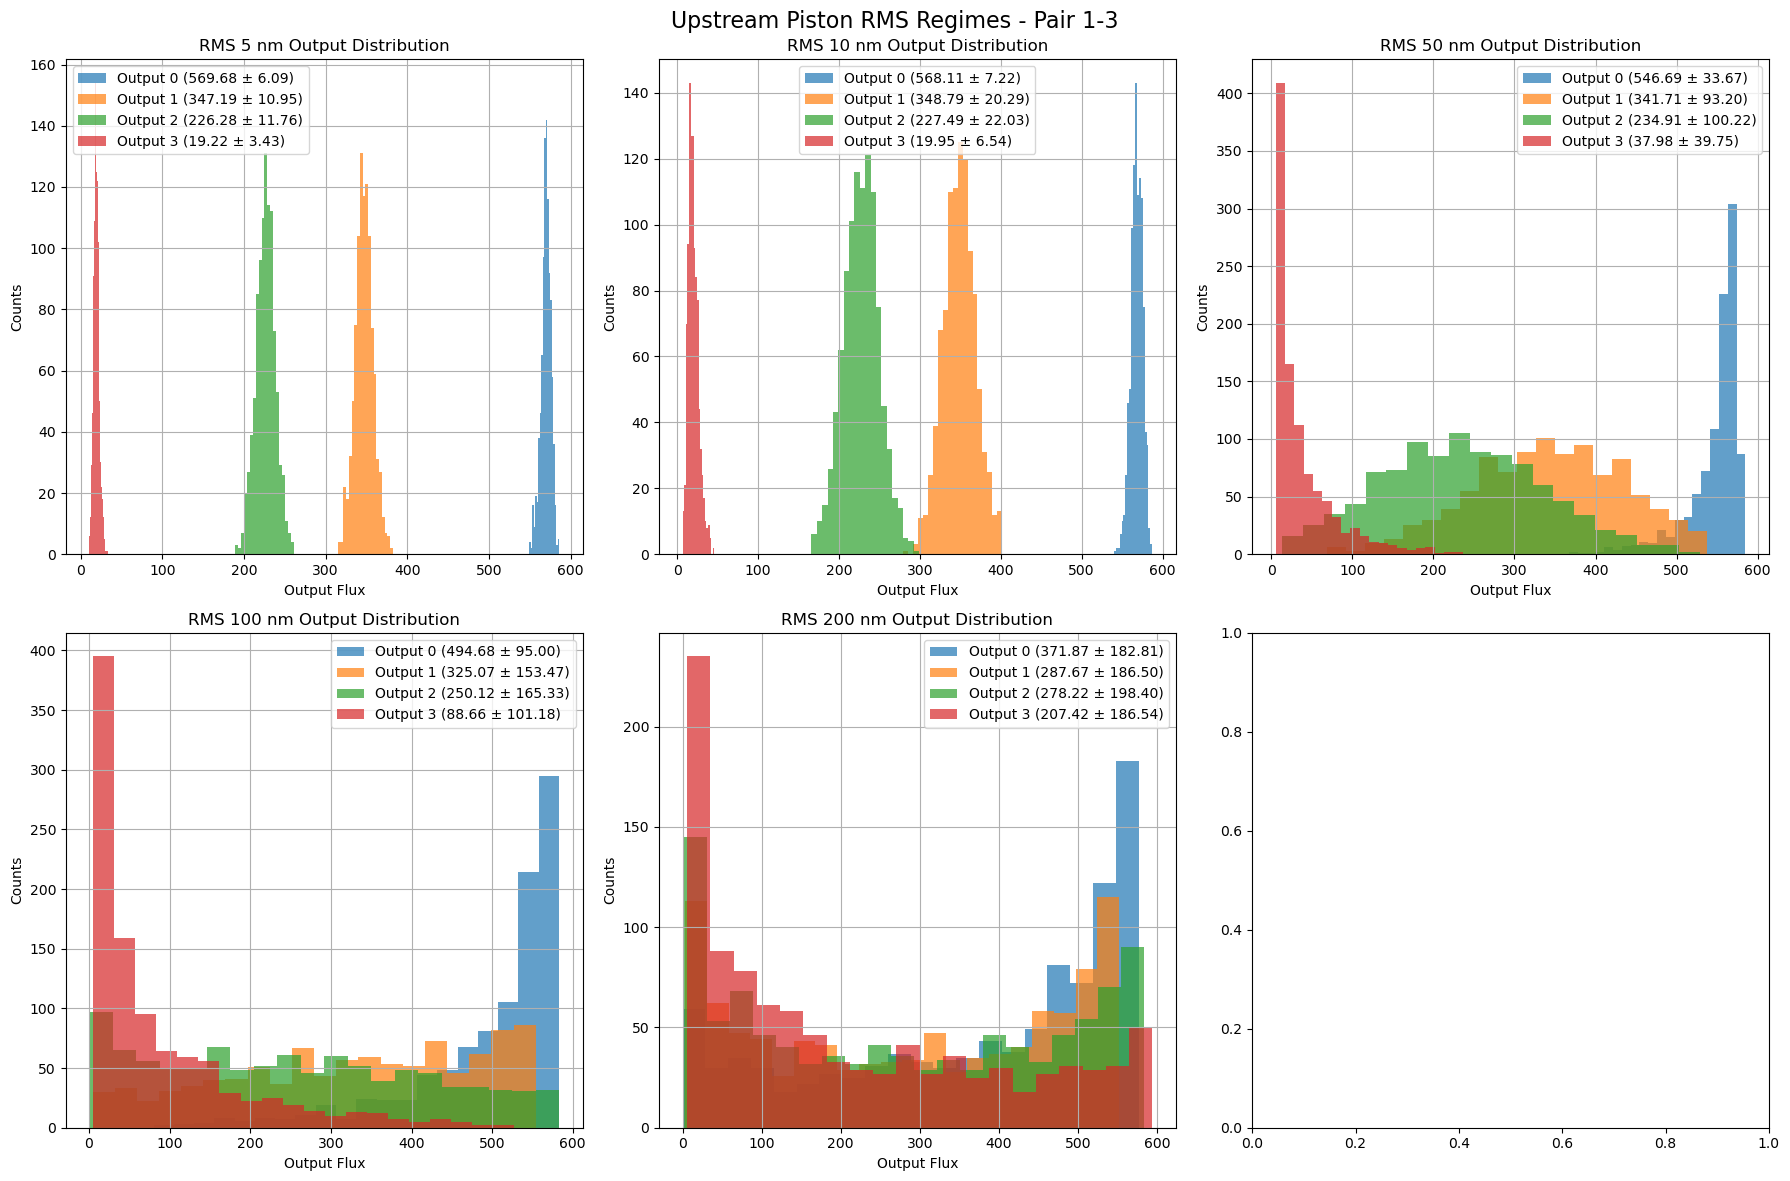

In [16]:
pair = (1, 3)
rms_values = [5, 10, 50, 100, 200] # [nm]
res_rms = rms_scan(1000, rms_values[:], lam, pair, False, True)

filename = 'fig_rms_pair_%s-%s.png'%(pair[0], pair[1])
try:
    res_rms['figure'].savefig(path / filename)
except:
    pass


In [17]:
filename = 'res_rms_pair_%s-%s.pkl'%(pair[0], pair[1])
with open(path / filename, 'wb') as f:
    pickle.dump(res_rms, f)

# Same with TOPA correction

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 3] (segments [137, 135])
Ref positions: -1150.0
Scanning RMS=5 nm...


100%|██████████| 1000/1000 [02:40<00:00,  6.25it/s]


Scanning RMS=10 nm...


100%|██████████| 1000/1000 [02:40<00:00,  6.25it/s]


Scanning RMS=50 nm...


...

Scanning RMS=100 nm...


100%|██████████| 1000/1000 [02:39<00:00,  6.25it/s]


Scanning RMS=200 nm...


100%|██████████| 1000/1000 [02:39<00:00,  6.25it/s]


Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


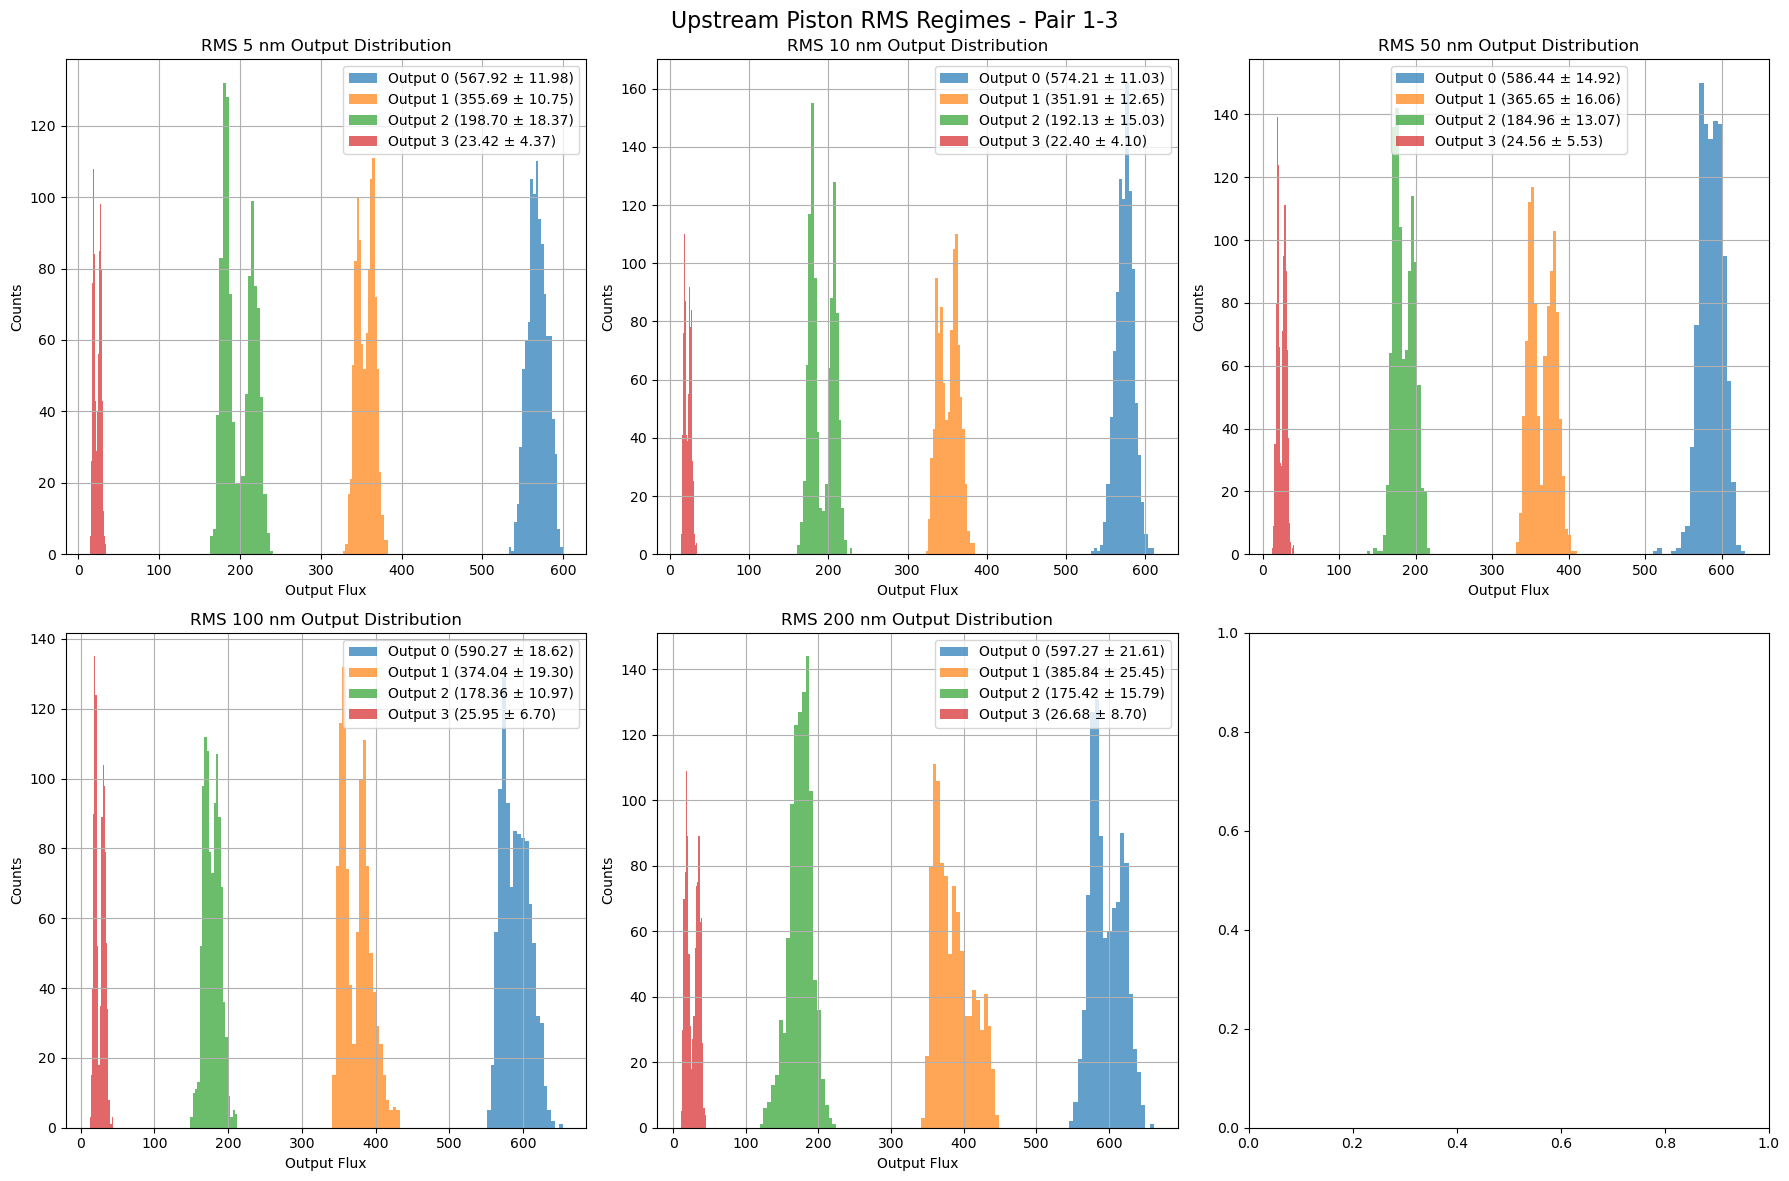

In [18]:
res_rms_corrected = rms_scan(1000, rms_values[:], lam, pair, True, True)
filename = 'fig_rms_corrected_pair_%s-%s.png'%(pair[0], pair[1])
res_rms_corrected['figure'].savefig(path / filename)

In [19]:
filename = 'res_rms_corrected_pair_%s-%s.pkl'%(pair[0], pair[1])
with open(path / filename, 'wb') as f:
    pickle.dump(res_rms_corrected, f)

# Same with the other pairs

## No TOPAS

In [ ]:
# pairs = [(0,1), (0,2), (0,3), (1,2), (2,3)]

# for pair in pairs:
#     res_rms = rms_scan(1000, rms_values[:], lam, pair, False, True)

#     filename = 'fig_rms_pair_%s-%s.png'%(pair[0], pair[1])
#     try:
#         res_rms['figure'].savefig(path / filename)
#     except:
#         pass

#     filename = 'res_rms_pair_%s-%s.pkl'%(pair[0], pair[1])
#     with open(path / filename, 'wb') as f:
#         pickle.dump(res_rms, f)

## With TOPAS

In [ ]:
# pairs = [(0,1), (0,2), (0,3), (1,2), (2,3)]

# for pair in pairs:
#     res_rms_corrected = rms_scan(1000, rms_values[:], lam, pair, True, True)
#     filename = 'fig_rms_corrected_pair_%s-%s.png'%(pair[0], pair[1])

#     try:
#         res_rms_corrected['figure'].savefig(path / filename)
#     except:
#         pass

#     filename = 'res_rms_corrected_pair_%s-%s.pkl'%(pair[0], pair[1])
#     with open(path / filename, 'wb') as f:
#         pickle.dump(res_rms_corrected, f)

# The end

In [28]:
phobos.XPOW().turn_off()
inj.zero()

Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
